In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('formatted_bench.csv')
df

,name,v,gr,max_procs,sec/op
0,ParallelBlocked,3,12,12,0.000024
1,ParallelBlocked,5,12,12,0.000032
2,ParallelBlocked,7,12,12,0.000034
3,ParallelBlocked,10,12,12,0.000044
4,ParallelBlocked,20,12,12,0.000100
...,...,...,...,...,...
94,Sequential,500,1,12,0.190817
95,Sequential,1000,1,12,1.491696
96,Sequential,2000,1,12,12.100815
97,Sequential,5000,1,12,183.509027


In [51]:
seq_df = df[df['name'] == 'Sequential']
seq_df = seq_df.reset_index(drop=True)
seq_df

,name,v,gr,max_procs,sec/op
0,Sequential,3,1,12,6.375000e-07
1,Sequential,5,1,12,8.960000e-07
2,Sequential,7,1,12,1.751000e-06
3,Sequential,10,1,12,4.650000e-06
4,Sequential,20,1,12,2.678300e-05
5,Sequential,50,1,12,3.630520e-04
6,Sequential,100,1,12,2.071641e-03
7,Sequential,500,1,12,1.908175e-01
8,Sequential,1000,1,12,1.491696e+00
9,Sequential,2000,1,12,1.210081e+01


In [52]:
seq_df['mcs/op'] = (seq_df['sec/op'] * (10 ** 6)).round(1).map(lambda x: f'{x:.1f}')
seq_df[['v', 'mcs/op']].set_index('v')

,mcs/op
v,
3,0.6
5,0.9
7,1.8
10,4.6
20,26.8
50,363.1
100,2071.6
500,190817.5
1000,1491696.2


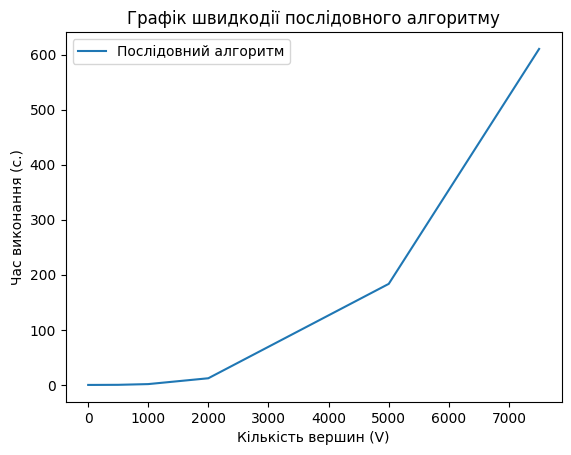

In [71]:
plt.plot(seq_df.v, seq_df['sec/op'], label='Послідовний алгоритм')
plt.legend()
plt.title('Графік швидкодії послідовного алгоритму')
plt.xlabel('Кількість вершин (V)')
plt.ylabel('Час виконання (с.)')
plt.show()

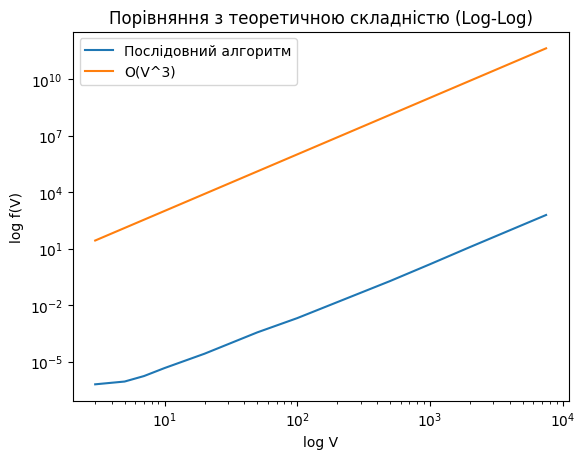

In [73]:
v_3 = seq_df.v ** 3
plt.loglog(seq_df.v, seq_df['sec/op'], label='Послідовний алгоритм')
plt.loglog(seq_df.v, v_3, label='O(V^3)')
plt.legend()
plt.title('Порівняння з теоретичною складністю (Log-Log)')
plt.xlabel('log V')
plt.ylabel('log f(V)')
plt.show()